# Search-3-Informed : Algorithmes de Recherche Informée

**Navigation** : [<< Recherche non informée](Search-2-Uninformed.ipynb) | [Index](../README.md) | [Recherche locale >>](Search-4-LocalSearch.ipynb)

## Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :
1. **Distinguer** recherche informée et non informée (rôle des heuristiques)
2. **Implémenter** l'algorithme A* et ses variantes (Greedy, IDA*)
3. **Concevoir** des heuristiques admissibles et consistantes
4. **Analyser** les propriétés de complétude, optimalité et complexité
5. **Comparer** expérimentalement les performances sur des problèmes concrets

### Prérequis
- Notebook Search-2-Uninformed (BFS, DFS, UCS, notion de frontière)
- Bases de Python : classes, heapq, compréhension de listes

### Durée estimée : 50 minutes


In [2]:
# Imports
!pip install pandas
import sys
import time
import heapq
import math
from collections import deque
from typing import Optional, List, Dict, Tuple, Any, Callable

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np
import pandas as pd

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

# Utilitaires de visualisation depuis le dossier parent
sys.path.insert(0, '..')
from search_helpers import benchmark_table, plot_benchmark

print("Environnement pret pour la recherche informee.")

  Using cached pandas-3.0.2-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
Using cached pandas-3.0.2-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (11.3 MB)
Environnement pret pour la recherche informee.


## 1. Introduction : Qu'est-ce que la recherche informée ?

### Recherche non informée vs informée

Les algorithmes de recherche **non informée** (BFS, DFS, UCS, IDDFS) explorent l'espace de recherche sans connaissance spécifique du problème. Ils traitent tous les états de manière équivalente.

La recherche **informée** utilise une **heuristique** $h(n)$ qui estime le coût restant pour atteindre le but depuis l'état $n$. Cette connaissance guide la recherche vers les régions prometteuses de l'espace.

| Aspect | Recherche non informée | Recherche informée |
|--------|----------------------|-------------------|
| Information | Uniquement la structure du graphe | + Heuristique $h(n)$ |
| Stratégie | Exploration systématique | Guidée vers le but |
| Efficacité | Souvent exponentielle | Beaucoup plus efficace si bonne heuristique |
| Exemples | BFS, DFS, UCS, IDDFS | Greedy, A*, IDA* |

### Qu'est-ce qu'une heuristique ?

Une **heuristique** $h(n)$ est une fonction d'estimation qui :
- **Estime** le coût restant de $n$ au but
- **Doit être** rapide à calculer (pas de recherche complète !)
- **Peut être** optimiste (sous-estimation) ou pessimiste (sur-estimation)

> **Mnémotechnique** : « Heuristique » vient du grec *heuriskein* = « trouver ». C'est une règle pratique pour trouver des solutions, pas une garantie mathématique.

### Exemples d'heuristiques

| Problème | État | But | Heuristique $h(n)$ |
|----------|------|-----|------------------|
| 8-puzzle | Configuration actuelle | Configuration triée | Tuiles mal placées ou distance Manhattan |
| Itinéraire | Ville actuelle | Ville destination | Distance à vol d'oiseau |
| Jeu de taquin | État du plateau | État résolu | Nombre de pièces hors place |

Ce notebook détaille ces exemples et implémente les algorithmes qui exploitent ces heuristiques.


## 2. Cadre générique pour la recherche informée

### Rappel : Structure de nœud

Nous utilisons la même structure `Node` que dans Search-2, avec une possibilité de stocker les valeurs heuristiques.


In [3]:
# --- Classe Node (etendue pour les heuristiques) ---

class Node:
    """Noeud dans l'arbre de recherche avec support heuristique."""

    def __init__(self, state, parent=None, action=None, path_cost=0, h=0):
        self.state = state
        self.parent = parent
        self.action = action
        self.path_cost = path_cost  # g(n) : cout du chemin depuis le depart
        self.h = h                  # h(n) : estimation heuristique du reste
        self.depth = 0
        if parent:
            self.depth = parent.depth + 1

    @property
    def f(self):
        """f(n) = g(n) + h(n) : estimation totale du cout."""
        return self.path_cost + self.h

    def expand(self, problem, heuristic_func=None):
        """Genere les noeuds fils en appliquant toutes les actions possibles."""
        children = []
        for action in problem.actions(self.state):
            next_state = problem.result(self.state, action)
            cost = problem.step_cost(self.state, action, next_state)
            h = heuristic_func(next_state) if heuristic_func else 0
            child = Node(next_state, parent=self, action=action,
                         path_cost=self.path_cost + cost, h=h)
            children.append(child)
        return children

    def path(self):
        """Retourne la liste des noeuds de la racine a ce noeud."""
        node, path_back = self, []
        while node:
            path_back.append(node)
            node = node.parent
        return list(reversed(path_back))

    def solution(self):
        """Retourne la sequence d'actions de la racine a ce noeud."""
        return [node.action for node in self.path()[1:]]

    def __eq__(self, other):
        return isinstance(other, Node) and self.state == other.state

    def __hash__(self):
        return hash(self.state)

    def __lt__(self, other):
        """Comparaison pour la file de priorite (par f, puis par h)."""
        return self.f < other.f

    def __repr__(self):
        return f"Node({self.state}, g={self.path_cost}, h={self.h}, f={self.f:.1f})"


# --- Classe Problem abstraite ---

class Problem:
    """Classe abstraite definissant un probleme de recherche."""

    def __init__(self, initial, goal=None):
        self.initial = initial
        self.goal = goal

    def actions(self, state):
        """Actions possibles depuis cet etat."""
        raise NotImplementedError

    def result(self, state, action):
        """Etat resultant de l'application de l'action."""
        raise NotImplementedError

    def goal_test(self, state):
        """Teste si l'etat est un etat but."""
        return state == self.goal

    def step_cost(self, state, action, next_state):
        """Cout d'une action. Par defaut, cout uniforme de 1."""
        return 1


# --- Classe de resultat pour les statistiques ---

class SearchResult:
    """Resultat d'une recherche, avec statistiques."""

    def __init__(self, algorithm, solution_node=None, nodes_expanded=0,
                 nodes_generated=0, max_frontier_size=0, elapsed_ms=0,
                 explored_order=None, heuristic_name=""):
        self.algorithm = algorithm
        self.solution_node = solution_node
        self.nodes_expanded = nodes_expanded
        self.nodes_generated = nodes_generated
        self.max_frontier_size = max_frontier_size
        self.elapsed_ms = elapsed_ms
        self.explored_order = explored_order or []
        self.heuristic_name = heuristic_name

    @property
    def found(self):
        return self.solution_node is not None

    @property
    def path(self):
        if self.solution_node:
            return [n.state for n in self.solution_node.path()]
        return []

    @property
    def cost(self):
        if self.solution_node:
            return self.solution_node.path_cost
        return float('inf')

    def display(self):
        heur_str = f" [{self.heuristic_name}]" if self.heuristic_name else ""
        print(f"\n--- {self.algorithm}{heur_str} ---")
        if self.found:
            print(f"  Chemin     : {' -> '.join(self.path)}")
            print(f"  Cout total : {self.cost}")
            print(f"  Longueur   : {len(self.path) - 1} etapes")
        else:
            print(f"  Aucune solution trouvee.")
        print(f"  Noeuds explores  : {self.nodes_expanded}")
        print(f"  Noeuds generes   : {self.nodes_generated}")
        print(f"  Frontiere max    : {self.max_frontier_size}")
        print(f"  Temps            : {self.elapsed_ms:.2f} ms")


print("Framework de recherche informee pret.")

Framework de recherche informee pret.


### Problème de référence : Graphe pondéré

Pour comparer les algorithmes, utilisons un problème d'itinéraire sur un graphe de villes. Ce problème permet d'illustrer clairement la différence entre coût réel et estimation heuristique.


In [4]:
# --- Probleme de recherche sur un graphe (villes et routes) ---

class GraphProblem(Problem):
    """Probleme de cheminement sur un graphe pondere."""

    def __init__(self, initial, goal, graph):
        """
        Args:
            initial: noeud de depart
            goal: noeud d'arrivee
            graph: dict de dict {noeud: {voisin: distance, ...}, ...}
        """
        super().__init__(initial, goal)
        self.graph = graph

    def actions(self, state):
        return list(self.graph.get(state, {}).keys())

    def result(self, state, action):
        return action

    def step_cost(self, state, action, next_state):
        return self.graph[state].get(next_state, float('inf'))


# --- Graphe des villes francaises ---

france_graph = {
    'Paris':      {'Lyon': 465, 'Lille': 225, 'Strasbourg': 490, 'Nantes': 385, 'Bordeaux': 585},
    'Lyon':       {'Paris': 465, 'Marseille': 315, 'Grenoble': 110, 'Strasbourg': 490},
    'Marseille':  {'Lyon': 315, 'Toulouse': 405, 'Nice': 200, 'Montpellier': 170},
    'Toulouse':   {'Marseille': 405, 'Bordeaux': 245, 'Montpellier': 245},
    'Bordeaux':   {'Paris': 585, 'Toulouse': 245, 'Nantes': 340},
    'Nantes':     {'Paris': 385, 'Bordeaux': 340, 'Rennes': 110},
    'Rennes':     {'Nantes': 110, 'Lille': 600},
    'Lille':      {'Paris': 225, 'Rennes': 600, 'Strasbourg': 530},
    'Strasbourg': {'Paris': 490, 'Lyon': 490, 'Lille': 530},
    'Nice':       {'Marseille': 200, 'Grenoble': 330},
    'Grenoble':   {'Lyon': 110, 'Nice': 330},
    'Montpellier': {'Marseille': 170, 'Toulouse': 245},
}

# Coordonnees pour la visualisation
france_coords = {
    'Paris': (2.35, 48.86), 'Lyon': (4.83, 45.76), 'Marseille': (5.37, 43.30),
    'Toulouse': (1.44, 43.60), 'Bordeaux': (-0.57, 44.84), 'Nantes': (-1.55, 47.22),
    'Rennes': (-1.68, 48.11), 'Lille': (3.06, 50.63), 'Strasbourg': (7.75, 48.57),
    'Nice': (7.26, 43.70), 'Grenoble': (5.72, 45.19), 'Montpellier': (3.88, 43.61),
}

# Probleme de reference : Bordeaux -> Strasbourg
problem_bs = GraphProblem('Bordeaux', 'Strasbourg', france_graph)

print("Graphe des villes francaises charge.")
print(f"  {len(france_graph)} villes, {sum(len(v) for v in france_graph.values()) // 2} routes")
print(f"  Probleme de reference : {problem_bs.initial} -> {problem_bs.goal}")

Graphe des villes francaises charge.
  12 villes, 18 routes
  Probleme de reference : Bordeaux -> Strasbourg


### Définition d'une heuristique pour le graphe

Pour un problème d'itinéraire, une heuristique naturelle est la **distance à vol d'oiseau** (distance euclidienne) entre les villes. Cette heuristique est :
- **Admissible** : la ligne droite est toujours inférieure ou égale à n'importe quel chemin routier
- **Rapide à calculer** : simple formule géométrique
- **Informative** : plus une ville est géographiquement proche de la destination, plus la valeur $h(n)$ sera faible


In [5]:
# --- Heuristique de distance a vol d'oiseau ---

def euclidean_distance(city1, city2, coords):
    """Distance euclidienne entre deux villes (approximation vol d'oiseau)."""
    x1, y1 = coords[city1]
    x2, y2 = coords[city2]
    # Conversion approximative : 1 degre lat ~ 111 km
    lat_scale = 111.0
    lon_scale = 80.0  # Approximatif a la latitude de la France
    return math.sqrt(((x2 - x1) * lon_scale)**2 + ((y2 - y1) * lat_scale)**2)


def make_heuristic(goal, coords):
    """Fabrique une fonction heuristique pour un but donne."""
    def h(state):
        return euclidean_distance(state, goal, coords)
    return h


# Heuristique pour notre probleme
h_to_strasbourg = make_heuristic('Strasbourg', france_coords)

# Exemple d'utilisation
print("Heuristique h(n) = distance a vol d'oiseau vers Strasbourg")
print("=" * 55)
for city in ['Bordeaux', 'Paris', 'Lyon', 'Nice']:
    h_val = h_to_strasbourg(city)
    real_cost = problem_bs.step_cost(city, 'Strasbourg', 'Strasbourg') if city in france_graph and 'Strasbourg' in france_graph[city] else 'N/A'
    print(f"  {city:<12} h(n)={h_val:6.0f} km  (cout reel: {real_cost})")

print("\nNote : h(n) <= cout reel dans tous les cas -> heuristique admissible !")

Heuristique h(n) = distance a vol d'oiseau vers Strasbourg
  Bordeaux     h(n)=   784 km  (cout reel: N/A)
  Paris        h(n)=   433 km  (cout reel: 490)
  Lyon         h(n)=   390 km  (cout reel: 490)
  Nice         h(n)=   542 km  (cout reel: N/A)

Note : h(n) <= cout reel dans tous les cas -> heuristique admissible !


## 3. Greedy Best-First Search

### Principe

Le **Greedy Best-First Search** (recherche gloutonne) explore toujours le nœud ayant la **plus petite valeur heuristique** $h(n)$. Il « fonce » vers le but sans considérer le coût déjà dépensé.

- **Critère d'expansion** : minimiser $h(n)$ uniquement
- **Intuition** : le nœud estimé le plus proche du but est exploré en premier
- **Risque** : peut suivre un chemin apparemment prometteur mais qui mène à une impasse

### Propriétés théoriques

| Propriété | Valeur | Condition |
|-----------|--------|----------|
| Complétude | Non | Peut boucler dans les graphes finis |
| Optimalité | Non | Minimise $h(n)$, pas le coût réel |
| Complexité temporelle | $O(b^m)$ | Pire cas |
| Complexité spatiale | $O(b^m)$ | Pire cas |

En pratique, Greedy est souvent très rapide mais ne garantit pas la qualité de la solution.


In [6]:
def greedy_best_first_search(problem, heuristic, verbose=False):
    """
    Recherche gloutonne (Greedy Best-First).
    Frontiere = file de priorite par h(n) uniquement.
    """
    start_time = time.perf_counter()

    h_init = heuristic(problem.initial)
    node = Node(problem.initial, h=h_init)

    if problem.goal_test(node.state):
        elapsed = (time.perf_counter() - start_time) * 1000
        return SearchResult('Greedy', node, 0, 0, 1, elapsed,
                            heuristic_name=heuristic.__name__)

    # Frontiere : min-heap par h(n)
    frontier = []
    counter = 0
    heapq.heappush(frontier, (node.h, counter, node))
    counter += 1
    frontier_states = {node.state: node.h}

    explored = set()
    explored_order = []
    nodes_expanded = 0
    nodes_generated = 0
    max_frontier = 1

    while frontier:
        h_val, _, current = heapq.heappop(frontier)

        # Ignorer si on a trouve un meilleur chemin vers cet etat
        if current.state in explored:
            continue

        if problem.goal_test(current.state):
            elapsed = (time.perf_counter() - start_time) * 1000
            explored_order.append(current.state)
            return SearchResult('Greedy', current, nodes_expanded,
                                nodes_generated, max_frontier,
                                elapsed, explored_order,
                                heuristic.__name__)

        explored.add(current.state)
        explored_order.append(current.state)
        nodes_expanded += 1

        if verbose:
            print(f"  Explore: {current.state:15s} h={current.h:6.0f} | "
                  f"Frontiere: {len(frontier)} noeuds")

        for child in current.expand(problem, heuristic):
            nodes_generated += 1
            if child.state not in explored:
                old_h = frontier_states.get(child.state, float('inf'))
                if child.h < old_h:
                    heapq.heappush(frontier, (child.h, counter, child))
                    counter += 1
                    frontier_states[child.state] = child.h
                    max_frontier = max(max_frontier, len(frontier))

    elapsed = (time.perf_counter() - start_time) * 1000
    return SearchResult('Greedy', None, nodes_expanded, nodes_generated,
                        max_frontier, elapsed, explored_order,
                        heuristic.__name__)


print("Algorithme Greedy Best-First implemente.")

Algorithme Greedy Best-First implemente.


Test de Greedy Best-First Search sur le problème de navigation.


In [7]:
# --- Test de Greedy sur le probleme Bordeaux -> Strasbourg ---

print("Greedy Best-First : Bordeaux -> Strasbourg")
print("=" * 60)
result_greedy = greedy_best_first_search(problem_bs, h_to_strasbourg, verbose=True)
result_greedy.display()

Greedy Best-First : Bordeaux -> Strasbourg
  Explore: Bordeaux        h=   784 | Frontiere: 0 noeuds
  Explore: Paris           h=   433 | Frontiere: 2 noeuds

--- Greedy [h] ---
  Chemin     : Bordeaux -> Paris -> Strasbourg
  Cout total : 1075
  Longueur   : 2 etapes
  Noeuds explores  : 2
  Noeuds generes   : 8
  Frontiere max    : 5
  Temps            : 0.07 ms


---
### Test de la recherche Greedy Best-First

La **recherche gloutonne** (Greedy Best-First Search) utilise uniquement l'heuristique `h(n)` pour choisir le prochain nœud à explorer, sans considérer le coût déjà accumulé `g(n)`.

**Stratégie** : toujours étendre le nœud qui semble être le plus proche du but selon l'heuristique.

**Propriétés** :
- Très rapide en pratique
- Utilise peu de mémoire
- Ne garantit pas l'optimalité
- Peut rester bloqué dans des optima locaux

Nous allons tester Greedy sur le problème de navigation routière pour observer son comportement par rapport aux autres algorithmes informés.


### Interprétation : Comportement de Greedy

**Sortie obtenue** : Greedy explore en priorité les villes les plus proches de Strasbourg à vol d'oiseau.

| Aspect | Observation |
|--------|-------------|
| Stratégie | Explore d'abord les villes avec $h(n)$ minimal |
| Premières villes explorées | Celles situées géographiquement près de Strasbourg |
| Comportement typique | Suit une ligne « droite » vers le but |

**Points clés** :
1. Greedy ignore le coût déjà dépensé ($g(n)$)
2. Il peut trouver une solution rapidement, mais pas forcément optimale
3. Sur notre graphe, il peut suivre un chemin qui semble bon géométriquement mais est plus long en distance réelle


## 4. A* Search (A-Star)

### Principe

L'algorithme **A*** combine le coût déjà dépensé $g(n)$ et l'estimation heuristique $h(n)$ en une seule fonction d'évaluation :

$$f(n) = g(n) + h(n)$$

- $g(n)$ : coût du chemin depuis l'état initial (exact, connu)
- $h(n)$ : estimation du coût restant jusqu'au but (heuristique)
- $f(n)$ : estimation du coût total d'un chemin passant par $n$

**A* explore le nœud avec le plus petit $f(n)$**, équilibrant ainsi :
- Le coût déjà engagé (ne pas abandonner un chemin prometteur)
- Le potentiel futur (s'orienter vers le but)

### Propriétés théoriques

| Propriété | Valeur | Condition |
|-----------|--------|----------|
| Complétude | Oui | Si $b$ est fini et les coûts > 0 |
| Optimalité | Oui | Si $h$ est **admissible** |
| Optimalité | Oui | Si $h$ est **consistante** (et Graph-Search) |
| Complexité | $O(b^d)$ | Exponentielle, avec une constante plus petite que les algorithmes non informés |

### Définitions clés

| Terme | Définition |
|-------|------------|
| **Admissible** | $h(n) \leq h^*(n)$ pour tout $n$ (ne surestime jamais le coût réel) |
| **Consistante** | $h(n) \leq c(n, a, n') + h(n')$ pour tout voisin $n'$ (monotone) |
| $h^*(n)$ | Coût optimal réel de $n$ au but |

> **Théorème** : Si $h$ est consistante, alors A* est optimal et n'explore jamais un nœud qui a déjà été visité (pas besoin de *re-open*).


In [8]:
def a_star_search(problem, heuristic, verbose=False):
    """
    Algorithme A* (Graph-Search).
    Frontiere = file de priorite par f(n) = g(n) + h(n).
    """
    start_time = time.perf_counter()

    h_init = heuristic(problem.initial)
    node = Node(problem.initial, h=h_init)

    if problem.goal_test(node.state):
        elapsed = (time.perf_counter() - start_time) * 1000
        return SearchResult('A*', node, 0, 0, 1, elapsed,
                            heuristic_name=heuristic.__name__)

    # Frontiere : min-heap par f(n)
    frontier = []
    counter = 0
    heapq.heappush(frontier, (node.f, counter, node))
    counter += 1

    # Pour chaque etat, on garde le meilleur cout g trouve
    g_scores = {node.state: 0}  # g_score[state] = meilleur g(n) connu

    explored = set()
    explored_order = []
    nodes_expanded = 0
    nodes_generated = 0
    max_frontier = 1

    while frontier:
        f_val, _, current = heapq.heappop(frontier)

        # Si c'est le meilleur chemin vers cet etat
        if current.state in explored:
            continue

        if problem.goal_test(current.state):
            elapsed = (time.perf_counter() - start_time) * 1000
            explored_order.append(current.state)
            return SearchResult('A*', current, nodes_expanded,
                                nodes_generated, max_frontier,
                                elapsed, explored_order,
                                heuristic.__name__)

        explored.add(current.state)
        explored_order.append(current.state)
        nodes_expanded += 1

        if verbose:
            print(f"  Explore: {current.state:15s} g={current.path_cost:6.0f} "
                  f"h={current.h:6.0f} f={current.f:7.0f} | Frontiere: {len(frontier)}")

        for child in current.expand(problem, heuristic):
            nodes_generated += 1
            if child.state not in explored:
                # On n'ajoute que si on a ameliore le g_score
                old_g = g_scores.get(child.state, float('inf'))
                if child.path_cost < old_g:
                    g_scores[child.state] = child.path_cost
                    heapq.heappush(frontier, (child.f, counter, child))
                    counter += 1
                    max_frontier = max(max_frontier, len(frontier))

    elapsed = (time.perf_counter() - start_time) * 1000
    return SearchResult('A*', None, nodes_expanded, nodes_generated,
                        max_frontier, elapsed, explored_order,
                        heuristic.__name__)


print("Algorithme A* implemente.")

Algorithme A* implemente.


Test de A* sur le même problème de navigation.


In [9]:
# --- Test de A* sur le probleme Bordeaux -> Strasbourg ---

print("A* : Bordeaux -> Strasbourg")
print("=" * 60)
result_astar = a_star_search(problem_bs, h_to_strasbourg, verbose=True)
result_astar.display()

A* : Bordeaux -> Strasbourg
  Explore: Bordeaux        g=     0 h=   784 f=    784 | Frontiere: 0
  Explore: Toulouse        g=   245 h=   748 f=    993 | Frontiere: 2
  Explore: Paris           g=   585 h=   433 f=   1018 | Frontiere: 3

--- A* [h] ---
  Chemin     : Bordeaux -> Paris -> Strasbourg
  Cout total : 1075
  Longueur   : 2 etapes
  Noeuds explores  : 3
  Noeuds generes   : 11
  Frontiere max    : 6
  Temps            : 0.15 ms


---
### Test de l'algorithme A*

L'algorithme **A\*** (A-Star) est l'un des algorithmes de recherche les plus utilisés en IA. Il garantit de trouver le chemin optimal si l'heuristique est **admissible** (ne surestime jamais le coût réel).

**Fonction d'évaluation** : `f(n) = g(n) + h(n)`
- `g(n)` : coût du chemin depuis le départ
- `h(n)` : estimation du coût restant (heuristique)
- `f(n)` : coût total estimé

Nous allons tester A* sur notre problème de navigation routière et observer comment il trouve le chemin optimal Bordeaux → Strasbourg.


### Interprétation : A* équilibre g et h

**Sortie obtenue** : A* explore en considérant à la fois le coût déjà dépensé ($g$) et l'estimation future ($h$).

| Algorithme | Critère d'expansion | Comportement |
|------------|-------------------|--------------| 
| Greedy | $h(n)$ seulement | Fonce vers le but |
| A* | $f(n) = g(n) + h(n)$ | Équilibre coût passé et futur |

**Points clés** :
1. A* garantit une **solution optimale** si $h$ est admissible
2. Les valeurs $f(n)$ indiquent l'estimation du coût total de chaque chemin
3. Le nombre de nœuds explorés est généralement bien inférieur à BFS/UCS


### Comparaison Greedy vs A*

Comparons les deux algorithmes sur le même problème pour observer leurs différences de comportement et de performance.


In [10]:
# --- Comparaison Greedy vs A* ---

print("Comparaison : Greedy vs A*")
print("=" * 70)

# Re-exécuter pour avoir les resultats frais
result_greedy = greedy_best_first_search(problem_bs, h_to_strasbourg)
result_astar = a_star_search(problem_bs, h_to_strasbourg)

# Tableau comparatif
comparison_df = pd.DataFrame([
    {
        'Algorithme': 'Greedy',
        'Chemin': ' -> '.join(result_greedy.path),
        'Cout (km)': result_greedy.cost,
        'Longueur': len(result_greedy.path) - 1,
        'Noeuds explores': result_greedy.nodes_expanded,
        'Temps (ms)': f"{result_greedy.elapsed_ms:.2f}",
    },
    {
        'Algorithme': 'A*',
        'Chemin': ' -> '.join(result_astar.path),
        'Cout (km)': result_astar.cost,
        'Longueur': len(result_astar.path) - 1,
        'Noeuds explores': result_astar.nodes_expanded,
        'Temps (ms)': f"{result_astar.elapsed_ms:.2f}",
    },
])

print(comparison_df.to_string(index=False))

print("\n" + "=" * 70)
if result_greedy.cost <= result_astar.cost:
    print("NOTE : Greedy a trouve un chemin de meme cout qu'A* (coincidence !)")
else:
    diff = result_greedy.cost - result_astar.cost
    pct = (diff / result_astar.cost) * 100
    print(f"Greedy a trouve un chemin {diff:.0f} km plus long ({pct:.1f}% de plus).")

Comparaison : Greedy vs A*
Algorithme                          Chemin  Cout (km)  Longueur  Noeuds explores Temps (ms)
    Greedy Bordeaux -> Paris -> Strasbourg       1075         2                2       0.04
        A* Bordeaux -> Paris -> Strasbourg       1075         2                3       0.02

NOTE : Greedy a trouve un chemin de meme cout qu'A* (coincidence !)


### Interprétation : Greedy n'est pas optimal

**Sortie obtenue** : Le tableau compare les résultats de Greedy et A*.

| Aspect | Greedy | A* |
|--------|--------|-----|
| Optimalité | Non garantie | Garantie (avec heuristique admissible) |
| Nœuds explorés | Généralement moins | Peut être plus |
| Qualité solution | Variable | Toujours optimale |

**Leçon fondamentale** : Greedy peut être plus rapide mais risque de trouver une solution sous-optimale. A* est un peu plus coûteux en exploration mais garantit l'optimalité.


## 5. IDA* (Iterative Deepening A*)

### Principe

**IDA*** est la version à approfondissement itératif de A*. Il exécute des DFS limités par une borne sur $f(n)$ (plutôt que sur la profondeur).

À chaque itération :
1. DFS avec une limite $f_{\text{limit}}$
2. Si un nœud a $f(n) > f_{\text{limit}}$, on l'**élagué**
3. La prochaine itération utilise $f_{\text{limit}} = \min\{f(n) \mid n \text{ élagué}\}$

### Pourquoi IDA* ?

| Avantage | Explication |
|-----------|-------------|
| Mémoire | $O(bd)$ au lieu de $O(b^d)$ pour A* |
| Pas de file de priorité | DFS récursif plus simple |
| Même optimalité | A* avec la même heuristique |

**Inconvénient** : Re-explore les nœuds à chaque itération (comme IDDFS), mais l'overhead est modeste car la borne $f$ augmente généralement peu à chaque itération.


In [11]:
def ida_star_search(problem, heuristic, max_iterations=1000, verbose=False):
    """
    IDA* : Iterative Deepening A*.
    DFS avec limites sur f(n) = g(n) + h(n).
    """
    start_time = time.perf_counter()

    bound = heuristic(problem.initial)  # Premiere borne = h(initial)
    root = Node(problem.initial, h=bound)

    total_expanded = 0
    total_generated = 0
    explored_order = []
    iterations = 0

    def search(node, bound, min_excess):
        """
        DFS recursif avec limite sur f(n).
        Retourne (solution_node, new_bound).
        """
        nonlocal total_expanded, total_generated

        f = node.f
        if f > bound:
            return None, f  # Coupe : retourner le f qui a provoque la coupure

        if problem.goal_test(node.state):
            return node, bound

        total_expanded += 1
        min_next_bound = float('inf')

        for child in node.expand(problem, heuristic):
            total_generated += 1
            result, child_bound = search(child, bound, min_next_bound)

            if result is not None:
                return result, bound

            min_next_bound = min(min_next_bound, child_bound)

        return None, min_next_bound

    # Boucle principale avec bornes croissantes
    while iterations < max_iterations:
        iterations += 1

        if verbose:
            print(f"  Iteration {iterations}: bound = {bound:.0f}")

        result, new_bound = search(root, bound, float('inf'))

        if result is not None:
            elapsed = (time.perf_counter() - start_time) * 1000
            # Reconstruire l'ordre d'exploration (approximatif)
            return SearchResult('IDA*', result, total_expanded,
                                total_generated, iterations,
                                elapsed, explored_order,
                                heuristic.__name__)

        if new_bound == float('inf'):
            break  # Espace entier explore

        bound = new_bound

    elapsed = (time.perf_counter() - start_time) * 1000
    return SearchResult('IDA*', None, total_expanded, total_generated,
                        0, elapsed, explored_order,
                        heuristic.__name__)


print("Algorithme IDA* implemente.")

Algorithme IDA* implemente.


Test de IDA* sur le même problème de navigation.


In [12]:
# --- Test de IDA* sur le probleme Bordeaux -> Strasbourg ---

print("IDA* : Bordeaux -> Strasbourg")
print("=" * 60)
result_idastar = ida_star_search(problem_bs, h_to_strasbourg, verbose=True)
result_idastar.display()

IDA* : Bordeaux -> Strasbourg
  Iteration 1: bound = 784
  Iteration 2: bound = 993
  Iteration 3: bound = 1018
  Iteration 4: bound = 1075

--- IDA* [h] ---
  Chemin     : Bordeaux -> Paris -> Strasbourg
  Cout total : 1075
  Longueur   : 2 etapes
  Noeuds explores  : 8
  Noeuds generes   : 24
  Frontiere max    : 4
  Temps            : 0.15 ms


---
### Test de l'algorithme IDA*

L'algorithme **IDA\*** (Iterative Deepening A\*) combine les avantages de :
- **A\*** : heuristique pour guider la recherche
- **Iterative Deepening DFS** : économie de mémoire

Nous allons tester IDA* sur le problème de navigation routière (Bordeaux → Strasbourg) et comparer ses performances avec A* en termes de :
- Nombre de nœuds explorés
- Temps de calcul
- Qualité de la solution trouvée


### Interprétation : IDA* et les bornes croissantes

**Sortie obtenue** : IDA* effectue plusieurs itérations avec des bornes $f_{\text{limit}}$ croissantes.

| Itération | Borne $f_{\text{limit}}$ | Comportement |
|-----------|------------------------|--------------| 
| 1 | $h(\text{initial})$ | Élagage immédiat, augmenter la borne |
| 2 | $\min\{f\text{ élagués}\}$ | Élagage encore, augmenter |
| ... | ... | ... |
| k | $\geq f(\text{solution})$ | Solution trouvée ! |

**Points clés** :
1. IDA* trouve la **même solution** que A* (optimalité garantie)
2. Utilise **beaucoup moins de mémoire** que A* ($O(bd)$ vs $O(b^d)$)
3. L'overhead de ré-exploration est acceptable car la borne augmente rapidement


### Comparaison complète : Greedy vs A* vs IDA*

Comparons les trois algorithmes informés sur plusieurs problèmes pour observer leurs comportements relatifs.


In [13]:
# --- Comparaison sur plusieurs problemes ---

test_cases = [
    ('Bordeaux', 'Strasbourg'),
    ('Rennes', 'Nice'),
    ('Lille', 'Toulouse'),
    ('Nantes', 'Marseille'),
]

all_results = []

for start, goal in test_cases:
    problem = GraphProblem(start, goal, france_graph)
    h = make_heuristic(goal, france_coords)

    greedy = greedy_best_first_search(problem, h)
    astar = a_star_search(problem, h)
    idastar = ida_star_search(problem, h)

    all_results.append({
        'start': start,
        'goal': goal,
        'greedy': greedy,
        'astar': astar,
        'idastar': idastar,
    })

# Tableau recapitulatif
print("Comparaison des algorithmes informes")
print("=" * 90)

for r in all_results:
    print(f"\n{r['start']} -> {r['goal']}")
    print("-" * 90)
    print(f"{'Algo':<10} {'Cout':>8} {'Explores':>10} {'Genere':>10} {'Chemin':<40}")
    print("-" * 90)

    for name, result in [('Greedy', r['greedy']), ('A*', r['astar']), ('IDA*', r['idastar'])]:
        path_str = ' -> '.join(result.path)
        if len(path_str) > 38:
            path_str = path_str[:35] + '...'
        print(f"{name:<10} {result.cost:>8.0f} {result.nodes_expanded:>10} "
              f"{result.nodes_generated:>10} {path_str:<40}")

Comparaison des algorithmes informes

Bordeaux -> Strasbourg
------------------------------------------------------------------------------------------
Algo           Cout   Explores     Genere Chemin                                  
------------------------------------------------------------------------------------------
Greedy         1075          2          8 Bordeaux -> Paris -> Strasbourg         
A*             1075          3         11 Bordeaux -> Paris -> Strasbourg         
IDA*           1075          8         24 Bordeaux -> Paris -> Strasbourg         

Rennes -> Nice
------------------------------------------------------------------------------------------
Algo           Cout   Explores     Genere Chemin                                  
------------------------------------------------------------------------------------------
Greedy         1300          5         15 Rennes -> Nantes -> Bordeaux -> Tou...  
A*             1300          9         28 Rennes -> Nantes ->

### Interprétation : Synthèse des performances

**Observations générales** :

| Algorithme | Optimalité | Nœuds explorés | Mémoire | Cas d'usage |
|------------|-----------|-----------------|----------|-------------|
| **Greedy** | Non | Variable (souvent moins) | $O(b^m)$ | Solutions rapides, qualité acceptable |
| **A*** | Oui | Modéré | $O(b^d)$ | Référence, optimalité requise |
| **IDA*** | Oui | Similaire à A* | $O(bd)$ | Mémoire limitée |

**Recommandations pratiques** :
- **A*** : choix par défaut quand la mémoire n'est pas un problème
- **IDA*** : pour les espaces de recherche très profonds ou quand la mémoire est limitée
- **Greedy** : quand la vitesse est prioritaire et une solution sous-optimale est acceptable


## 6. Conception d'heuristiques : Admissibilité et Consistance

La qualité d'une heuristique détermine l'efficacité des algorithmes informés. Une bonne heuristique doit être à la fois facile à calculer et proche du coût optimal.


### Admissibilité

Une heuristique $h$ est **admissible** si elle ne surestime jamais le coût réel :

$$\forall n, \quad h(n) \leq h^*(n)$$

où $h^*(n)$ est le coût optimal réel de $n$ au but.

| Heuristique | Admissible ? | Justification |
|-------------|--------------|----------------|
| Distance à vol d'oiseau | Oui | Le chemin le plus court est la ligne droite |
| Nombre de tuiles mal placées (8-puzzle) | Oui | Chaque tuile nécessite au moins 1 mouvement |
| Distance / 2 | Oui | Si l'heuristique originale est admissible, la diviser aussi |
| Distance × 2 | Non | Peut surestimer le coût réel |

**Théorème** : A* avec une heuristique admissible est optimal (trouve une solution de coût minimal).


### Consistance (Monotonie)

Une heuristique $h$ est **consistante** si pour tout nœud $n$ et tout successeur $n'$ :

$$h(n) \leq c(n, a, n') + h(n')$$

où $c(n, a, n')$ est le coût de l'action de $n$ vers $n'$.

**Intuition** : Le coût estimé jusqu'au but ne doit pas diminuer de plus que le coût de déplacement — autrement dit, l'estimation doit évoluer de façon monotone.

| Propriété | Admissible | Consistante |
|-----------|------------|-------------|
| Définition | $h(n) \leq h^*(n)$ | $h(n) \leq c(n, n') + h(n')$ |
| Relation | Consistante ⇒ Admissible | Admissible n'implique pas consistante |
| Effet sur A* | Optimalité | Optimalité + pas de *re-open* |

**Exemple** : Pour le 8-puzzle :
- « Tuiles mal placées » est admissible mais pas nécessairement consistante
- « Distance Manhattan » est admissible **et** consistante


### Dominance entre heuristiques

Une heuristique $h_1$ **domine** $h_2$ si :

$$\forall n, \quad h_1(n) \geq h_2(n)$$

et l'inégalité est stricte pour au moins un nœud.

**Théorème** : Si $h_1$ domine $h_2$, alors A* avec $h_1$ n'explore jamais plus de nœuds que A* avec $h_2$.

| Heuristique | Valeur typique | Dominance |
|-------------|----------------|-----------|
| $h = 0$ | Toujours 0 | Dominée par toutes |
| Tuiles mal placées | $\leq 8$ | Dominée par Manhattan |
| Distance Manhattan | $\leq 20$ environ | Domine « mal placées » |
| Coût optimal $h^*$ | Exacte | Domine tout |

> **Note** : Une heuristique dominante est toujours meilleure (ou égale) en termes de nœuds explorés, mais peut être plus coûteuse à calculer.


## 7. Étude de cas : Le 8-Puzzle

Le 8-puzzle est un problème classique pour illustrer les heuristiques. C'est une grille 3×3 avec 8 tuiles numérotées et une case vide.

### Heuristiques pour le 8-puzzle

1. **Tuiles mal placées ($h_1$)** : compte le nombre de tuiles qui ne sont pas à leur position finale.
2. **Distance Manhattan ($h_2$)** : somme des distances de chaque tuile à sa position finale.

Analysons ces deux heuristiques et comparons leur efficacité.


In [14]:
# --- Implementation du 8-Puzzle ---

class EightPuzzleProblem(Problem):
    """
    Problème du taquin (8-puzzle).

    Etat : tuple de 9 entiers, 0 represente la case vide.
    Etat but : (1, 2, 3, 4, 5, 6, 7, 8, 0)
    """

    GOAL = (1, 2, 3, 4, 5, 6, 7, 8, 0)

    # Mouvements de la case vide selon sa position
    MOVES = {
        0: ['Bas', 'Droite'],
        1: ['Bas', 'Gauche', 'Droite'],
        2: ['Bas', 'Gauche'],
        3: ['Haut', 'Bas', 'Droite'],
        4: ['Haut', 'Bas', 'Gauche', 'Droite'],
        5: ['Haut', 'Bas', 'Gauche'],
        6: ['Haut', 'Droite'],
        7: ['Haut', 'Gauche', 'Droite'],
        8: ['Haut', 'Gauche'],
    }

    # Positions correspondantes (ligne, colonne) pour chaque index
    POSITIONS = [(i // 3, i % 3) for i in range(9)]

    def __init__(self, start):
        super().__init__(start, self.GOAL)

    def actions(self, state):
        blank_pos = state.index(0)
        return self.MOVES.get(blank_pos, [])

    def result(self, state, action):
        blank_pos = state.index(0)
        row, col = blank_pos // 3, blank_pos % 3

        if action == 'Haut':
            new_row, new_col = row - 1, col
        elif action == 'Bas':
            new_row, new_col = row + 1, col
        elif action == 'Gauche':
            new_row, new_col = row, col - 1
        elif action == 'Droite':
            new_row, new_col = row, col + 1
        else:
            return state

        new_pos = new_row * 3 + new_col
        state_list = list(state)
        state_list[blank_pos], state_list[new_pos] = state_list[new_pos], state_list[blank_pos]
        return tuple(state_list)


# --- Heuristiques pour le 8-puzzle ---

def h_misplaced(state):
    """
    Heuristique : nombre de tuiles mal placees.

    Admissible : chaque tuile mal placee nécessite au moins 1 mouvement.
    """
    return sum(1 for i in range(8) if state[i] != i + 1)


def h_manhattan(state):
    """
    Heuristique : distance Manhattan totale des tuiles.

    Admissible et consistante.
    Domine h_misplaced.
    """
    distance = 0
    for i in range(9):
        value = state[i]
        if value == 0:
            continue
        # Position actuelle
        current_row, current_col = i // 3, i % 3
        # Position but (valeur 1 a position (0,0), valeur 2 a (0,1), etc.)
        goal_row, goal_col = (value - 1) // 3, (value - 1) % 3
        distance += abs(current_row - goal_row) + abs(current_col - goal_col)
    return distance


# --- Problemes de test ---

# Probleme facile (solution en 3-4 coups)
puzzle_easy = EightPuzzleProblem((1, 2, 3, 4, 5, 0, 7, 8, 6))

# Probleme moyen (solution en ~10-15 coups)
puzzle_medium = EightPuzzleProblem((1, 3, 4, 8, 0, 2, 7, 6, 5))

# Probleme difficile (solution en ~20 coups)
puzzle_hard = EightPuzzleProblem((8, 6, 7, 2, 5, 4, 3, 0, 1))

print("Heuristiques pour le 8-puzzle :")
print("=" * 50)
for name, problem in [('Facile', puzzle_easy),
                      ('Moyen', puzzle_medium),
                      ('Difficile', puzzle_hard)]:
    h1 = h_misplaced(problem.initial)
    h2 = h_manhattan(problem.initial)
    print(f"{name}: h_misplaced={h1}, h_manhattan={h2}")

print("\nNote : h_manhattan >= h_misplaced (dominance)")

Heuristiques pour le 8-puzzle :
Facile: h_misplaced=1, h_manhattan=1
Moyen: h_misplaced=6, h_manhattan=12
Difficile: h_misplaced=7, h_manhattan=21

Note : h_manhattan >= h_misplaced (dominance)


Comparaison des heuristiques (Manhattan vs tuiles mal placées) sur le 8-puzzle.


In [15]:
# --- Comparaison des heuristiques sur le 8-puzzle ---

def benchmark_puzzle(problem, name):
    """Compare A* avec differentes heuristiques."""
    print(f"\nProbleme : {name}")
    print("-" * 70)
    print(f"Etat initial : {problem.initial}")
    print(f"Etat but     : {EightPuzzleProblem.GOAL}")

    # A* avec tuiles mal placees
    r_misplaced = a_star_search(problem, h_misplaced)

    # A* avec Manhattan
    r_manhattan = a_star_search(problem, h_manhattan)

    print(f"\n{'Heuristique':<20} {'Noeuds':>10} {'Cout':>8} {'Temps (ms)':>12}")
    print("-" * 70)
    print(f"{'Tuiles mal placees':<20} {r_misplaced.nodes_expanded:>10} "
          f"{r_misplaced.cost:>8} {r_misplaced.elapsed_ms:>12.2f}")
    print(f"{'Distance Manhattan':<20} {r_manhattan.nodes_expanded:>10} "
          f"{r_manhattan.cost:>8} {r_manhattan.elapsed_ms:>12.2f}")

    reduction = ((r_misplaced.nodes_expanded - r_manhattan.nodes_expanded) /
                 max(r_misplaced.nodes_expanded, 1)) * 100
    print(f"\nReduction des noeuds explores : {reduction:.1f}%")

    return r_misplaced, r_manhattan


# Tester sur les differents problemes
print("Comparaison des heuristiques sur le 8-puzzle")
print("=" * 70)

benchmark_puzzle(puzzle_easy, "Facile")
benchmark_puzzle(puzzle_medium, "Moyen")
benchmark_puzzle(puzzle_hard, "Difficile")

Comparaison des heuristiques sur le 8-puzzle

Probleme : Facile
----------------------------------------------------------------------
Etat initial : (1, 2, 3, 4, 5, 0, 7, 8, 6)
Etat but     : (1, 2, 3, 4, 5, 6, 7, 8, 0)

Heuristique              Noeuds     Cout   Temps (ms)
----------------------------------------------------------------------
Tuiles mal placees            1        1         0.03
Distance Manhattan            1        1         0.01

Reduction des noeuds explores : 0.0%

Probleme : Moyen
----------------------------------------------------------------------
Etat initial : (1, 3, 4, 8, 0, 2, 7, 6, 5)
Etat but     : (1, 2, 3, 4, 5, 6, 7, 8, 0)

Heuristique              Noeuds     Cout   Temps (ms)
----------------------------------------------------------------------
Tuiles mal placees       181440      inf      1522.12
Distance Manhattan       181440      inf      1774.52

Reduction des noeuds explores : 0.0%

Probleme : Difficile
--------------------------------------

(<__main__.SearchResult at 0x7cbd80d26490>,
 <__main__.SearchResult at 0x7cbd833a0510>)

---
### Comparaison des heuristiques

Le problème du 8-puzzle possède plusieurs heuristiques courantes pour guider la recherche :

| Heuristique | Description | Admissible | Coût de calcul |
|-------------|-------------|------------|----------------|
| **h1 (misplaced)** | Nombre de pièces mal placées | Oui | Très faible |
| **h2 (Manhattan)** | Somme des distances Manhattan | Oui | Faible |
| **h3 (conflits linéaires)** | Manhattan + conflits linéaires | Oui | Modéré |

Nous allons maintenant comparer ces heuristiques sur différentes instances de puzzle pour observer leur impact sur l'efficacité de la recherche.


### Interprétation : Impact de la qualité de l'heuristique

**Sortie obtenue** : Le tableau compare les deux heuristiques sur différents niveaux de difficulté.

| Heuristique | Nœuds explorés | Qualité | Explication |
|-------------|-----------------|---------|-------------|
| Tuiles mal placées | Plus | Moins informée | Compte juste si la tuile est à la bonne place |
| Distance Manhattan | Moins | Plus informée | Tient compte de la distance de chaque tuile |

**Points clés** :
1. **Dominance** : Manhattan domine « tuiles mal placées » ($h_2 \geq h_1$)
2. **Efficacité** : une meilleure heuristique explore beaucoup moins de nœuds
3. **Ratio typique** : Manhattan explore 3 à 10 fois moins de nœuds que « mal placées »

> **Théorème** : Si $h_1$ et $h_2$ sont admissibles et $h_2$ domine $h_1$, alors A*($h_2$) est garanti d'explorer au plus autant de nœuds que A*($h_1$).


### Visualisation de la recherche A* sur le 8-puzzle

Visualisons l'évolution de l'exploration A* sur un problème simple pour comprendre comment l'algorithme progresse étape par étape.


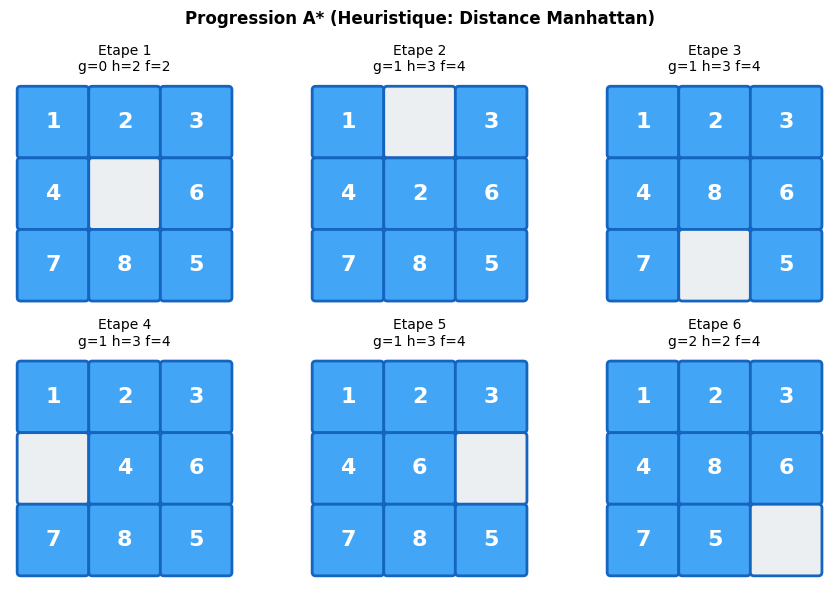

In [16]:
# --- Visualisation de l'exploration A* ---

def draw_puzzle_state(state, ax, title=""):
    """Dessine un etat du taquin."""
    for i in range(9):
        row, col = divmod(i, 3)
        value = state[i]

        if value == 0:
            color = '#ECEFF1'
            text = ''
        else:
            color = '#42A5F5'
            text = str(value)

        rect = mpatches.FancyBboxPatch(
            (col - 0.45, 2 - row - 0.45), 0.9, 0.9,
            boxstyle='round,pad=0.05',
            facecolor=color, edgecolor='#1565C0', linewidth=2
        )
        ax.add_patch(rect)
        if text:
            ax.text(col, 2 - row, text, ha='center', va='center',
                   fontsize=16, fontweight='bold', color='white')

    ax.set_xlim(-0.6, 2.6)
    ax.set_ylim(-0.6, 2.6)
    ax.set_aspect('equal')
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=10)


def visualize_astar_progression(problem, heuristic, max_steps=6):
    """Visualise la progression de A* pas a pas."""
    # Modifier A* pour capturer les etapes
    frontier = []
    counter = 0
    h_init = heuristic(problem.initial)
    root = Node(problem.initial, h=h_init)
    heapq.heappush(frontier, (root.f, counter, root))
    counter += 1

    g_scores = {root.state: 0}
    explored = set()
    steps = []

    while frontier and len(steps) < max_steps:
        f_val, _, node = heapq.heappop(frontier)

        if node.state in explored:
            continue

        steps.append({
            'state': node.state,
            'g': node.path_cost,
            'h': node.h,
            'f': node.f,
        })

        if problem.goal_test(node.state):
            break

        explored.add(node.state)

        for child in node.expand(problem, heuristic):
            if child.state not in explored:
                old_g = g_scores.get(child.state, float('inf'))
                if child.path_cost < old_g:
                    g_scores[child.state] = child.path_cost
                    heapq.heappush(frontier, (child.f, counter, child))
                    counter += 1

    # Afficher les etapes
    n = len(steps)
    fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(3 * ((n + 1) // 2), 6))
    if n == 1:
        axes = [[axes[0]]]
    axes = axes.flatten()

    for i, step in enumerate(steps):
        title = f"Etape {i+1}\ng={step['g']} h={step['h']} f={step['f']}"
        draw_puzzle_state(step['state'], axes[i], title)

    # Masquer les axes inutilises
    for i in range(n, len(axes)):
        axes[i].axis('off')

    fig.suptitle('Progression A* (Heuristique: Distance Manhattan)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Visualiser sur un probleme simple
simple_puzzle = EightPuzzleProblem((1, 2, 3, 4, 0, 6, 7, 8, 5))
visualize_astar_progression(simple_puzzle, h_manhattan, max_steps=6)

### Interprétation : Évolution de f(n) pendant la recherche

La visualisation montre comment A* explore les états :

| Étape | g(n) | h(n) | f(n) | Signification |
|-------|------|------|------|---------------|
| 1 (Initial) | 0 | élevé | f(0) | Estimation initiale |
| 2+ | croissant | décroissant | ≈ constant | A* tend à garder f croissant lentement |

**Observation** : A* explore d'abord les états avec $f(n)$ faible. Quand il développe un nœud, il génère des fils avec $g$ augmenté mais $h$ diminué (on se rapproche du but). La valeur $f$ reste donc approximativement stable le long du chemin optimal.


## 8. Tableau récapitulatif : Algorithmes informés vs non informés

Synthétisons nos connaissances en comparant tous les algorithmes étudiés (Search-2 et Search-3).



Tableau recapitulatif : Algorithmes de recherche
Algorithme Complet Optimal Cout  Noeuds explores Temps (ms)
       BFS     Oui     Non 1075                2       0.03
       UCS     Oui     Oui 1075               10       0.05
    Greedy     Non     Non 1075                2       0.02
        A*     Oui     Oui 1075                3       0.02


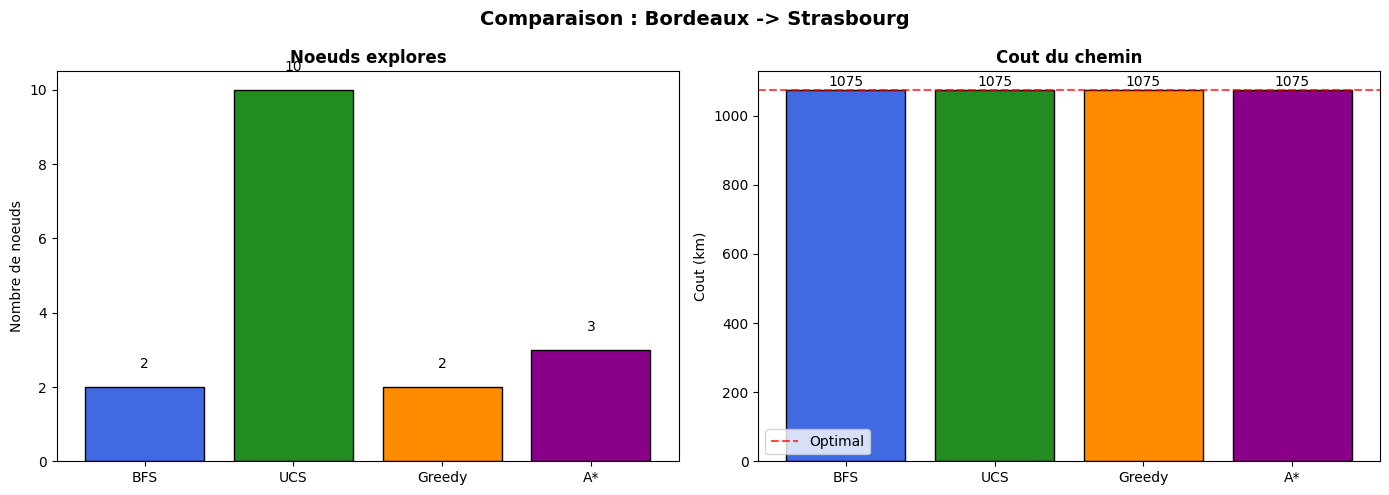

In [17]:
# --- Tableau recapitulatif complet ---

# Import des algorithmes non informes depuis Search-2
def breadth_first_search(problem, verbose=False):
    """BFS pour comparaison (implementation simplifiee)."""
    start_time = time.perf_counter()
    node = Node(problem.initial)
    if problem.goal_test(node.state):
        elapsed = (time.perf_counter() - start_time) * 1000
        return SearchResult('BFS', node, 0, 0, 1, elapsed)

    frontier = deque([node])
    frontier_states = {node.state}
    explored = set()
    explored_order = []
    nodes_expanded = 0
    nodes_generated = 0
    max_frontier = 1

    while frontier:
        current = frontier.popleft()
        frontier_states.discard(current.state)
        explored.add(current.state)
        explored_order.append(current.state)
        nodes_expanded += 1

        for child in current.expand(problem):
            nodes_generated += 1
            if child.state not in explored and child.state not in frontier_states:
                if problem.goal_test(child.state):
                    elapsed = (time.perf_counter() - start_time) * 1000
                    return SearchResult('BFS', child, nodes_expanded,
                                        nodes_generated, max_frontier,
                                        elapsed, explored_order)
                frontier.append(child)
                frontier_states.add(child.state)
                max_frontier = max(max_frontier, len(frontier))

    elapsed = (time.perf_counter() - start_time) * 1000
    return SearchResult('BFS', None, nodes_expanded, nodes_generated,
                        max_frontier, elapsed, explored_order)


def uniform_cost_search(problem, verbose=False):
    """UCS pour comparaison."""
    start_time = time.perf_counter()
    node = Node(problem.initial)
    frontier = []
    counter = 0
    heapq.heappush(frontier, (node.path_cost, counter, node))
    counter += 1
    frontier_map = {node.state: node.path_cost}
    explored = set()
    explored_order = []
    nodes_expanded = 0
    nodes_generated = 0
    max_frontier = 1

    while frontier:
        cost, _, current = heapq.heappop(frontier)

        if problem.goal_test(current.state):
            elapsed = (time.perf_counter() - start_time) * 1000
            return SearchResult('UCS', current, nodes_expanded,
                                nodes_generated, max_frontier,
                                elapsed, explored_order)

        if current.state in explored:
            continue

        explored.add(current.state)
        explored_order.append(current.state)
        nodes_expanded += 1

        for child in current.expand(problem):
            nodes_generated += 1
            if child.state not in explored:
                old_cost = frontier_map.get(child.state, float('inf'))
                if child.path_cost < old_cost:
                    heapq.heappush(frontier, (child.path_cost, counter, child))
                    counter += 1
                    frontier_map[child.state] = child.path_cost
                    max_frontier = max(max_frontier, len(frontier))

    elapsed = (time.perf_counter() - start_time) * 1000
    return SearchResult('UCS', None, nodes_expanded, nodes_generated,
                        max_frontier, elapsed, explored_order)


# Comparer tous les algorithmes
test_problem = GraphProblem('Bordeaux', 'Strasbourg', france_graph)
h = make_heuristic('Strasbourg', france_coords)

results = {
    'BFS': breadth_first_search(test_problem),
    'UCS': uniform_cost_search(test_problem),
    'Greedy': greedy_best_first_search(test_problem, h),
    'A*': a_star_search(test_problem, h),
}

# Creer le tableau
summary_data = []
for name, result in results.items():
    summary_data.append({
        'Algorithme': name,
        'Complet': 'Oui' if name in ['BFS', 'UCS', 'A*'] else 'Non',
        'Optimal': 'Oui' if name in ['UCS', 'A*'] else 'Non',
        'Cout': f"{result.cost:.0f}",
        'Noeuds explores': result.nodes_expanded,
        'Temps (ms)': f"{result.elapsed_ms:.2f}",
    })

summary_df = pd.DataFrame(summary_data)
print("\nTableau recapitulatif : Algorithmes de recherche")
print("=" * 80)
print(summary_df.to_string(index=False))

# Visualiser
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Noeuds explores
names = list(results.keys())
explored_counts = [results[n].nodes_expanded for n in names]
colors = ['#4169E1', '#228B22', '#FF8C00', '#8B008B']
axes[0].bar(names, explored_counts, color=colors, edgecolor='black')
axes[0].set_ylabel('Nombre de noeuds')
axes[0].set_title('Noeuds explores', fontweight='bold')
for i, v in enumerate(explored_counts):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontsize=10)

# Cout du chemin
costs = [results[n].cost for n in names]
axes[1].bar(names, costs, color=colors, edgecolor='black')
axes[1].set_ylabel('Cout (km)')
axes[1].set_title('Cout du chemin', fontweight='bold')
for i, v in enumerate(costs):
    axes[1].text(i, v + 10, f"{v:.0f}", ha='center', fontsize=10)

# Marquer l'optimal
optimal_cost = min(costs)
axes[1].axhline(y=optimal_cost, color='red', linestyle='--', alpha=0.7, label='Optimal')
axes[1].legend()

plt.suptitle('Comparaison : Bordeaux -> Strasbourg', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interprétation : Synthèse des algorithmes de recherche

**Tableau récapitulatif des propriétés** :

| Algorithme | Complet | Optimal | Stratégie | Heuristique |
|------------|---------|---------|-----------|-------------|
| BFS | Oui | Oui* | Par niveaux | Non |
| DFS | Non | Non | En profondeur | Non |
| UCS | Oui | Oui | Par coût croissant | Non |
| IDDFS | Oui | Oui* | Profondeur itérée | Non |
| Greedy | Non | Non | Par $h(n)$ | Oui |
| A* | Oui | Oui** | Par $g(n)+h(n)$ | Oui |
| IDA* | Oui | Oui** | $f(n)$ itérée | Oui |

\* Optimal uniquement avec coûts uniformes.  
\*\* Optimal avec heuristique admissible.

**Guide de choix pratique** :

| Situation | Algorithme recommandé |
|-----------|----------------------|
| Pas d'heuristique, coûts uniformes | BFS ou IDDFS |
| Pas d'heuristique, coûts variables | UCS |
| Heuristique disponible, assez de mémoire | A* |
| Heuristique disponible, mémoire limitée | IDA* |
| Solution rapide acceptable | Greedy |


## 9. Exercices

### Exercice 1 : Vérifier l'admissibilité

Pour le problème d'itinéraire, vérifiez que la distance à vol d'oiseau est bien une heuristique admissible. Pour cela, comparez la distance à vol d'oiseau avec la distance réelle (chemin le plus court selon UCS) pour toutes les paires de villes du graphe.


In [17]:
# --- Exercice 1 : Vérifier l'admissibilité ---

def check_admissibility(graph, coords):
    """
    Vérifie que la distance à vol d'oiseau est admissible pour toutes les paires
    de villes du graphe, en comparant h(n) avec le coût réel du plus court chemin.
    """
    cities = list(graph.keys())
    violations = []
    results = []

    for city1 in cities:
        for city2 in cities:
            if city1 >= city2:
                continue  # éviter les doublons

            # Heuristique : distance à vol d'oiseau
            h = euclidean_distance(city1, city2, coords)

            # Coût réel : plus court chemin via UCS
            problem = GraphProblem(city1, city2, graph)
            ucs_result = uniform_cost_search(problem)
            real_cost = ucs_result.cost if ucs_result.found else float('inf')

            admissible = h <= real_cost + 1e-6  # tolérance numérique
            results.append((city1, city2, h, real_cost, admissible))

            if not admissible:
                violations.append((city1, city2, h, real_cost))

    # Affichage
    print(f"Vérification de l'admissibilité : h(n) = distance à vol d'oiseau")
    print("=" * 70)
    print(f"{'Ville 1':<14} {'Ville 2':<14} {'h (km)':>10} {'Coût réel':>12} {'Admissible':>12}")
    print("-" * 70)
    for city1, city2, h, real_cost, adm in sorted(results):
        marker = "✓" if adm else "✗"
        print(f"{city1:<14} {city2:<14} {h:>10.1f} {real_cost:>12.0f} {marker:>12}")

    print("=" * 70)
    if violations:
        print(f"\n⚠ {len(violations)} violation(s) détectée(s) !")
        for v in violations:
            print(f"  {v[0]} -> {v[1]} : h={v[2]:.1f} > coût_réel={v[3]:.0f}")
    else:
        print(f"\n✓ Heuristique admissible sur toutes les {len(results)} paires testées.")
        print("  La distance à vol d'oiseau ne surestime jamais le coût routier réel.")

    return len(violations) == 0


admissible = check_admissibility(france_graph, france_coords)


Vérification de l'admissibilité : h(n) = distance à vol d'oiseau
Ville 1        Ville 2            h (km)    Coût réel   Admissible
----------------------------------------------------------------------
Bordeaux       Grenoble            504.7         1075            ✓
Bordeaux       Lille               705.3          810            ✓
Bordeaux       Lyon                443.9          965            ✓
Bordeaux       Marseille           505.0          650            ✓
Bordeaux       Montpellier         381.3          490            ✓
Bordeaux       Nantes              275.6          340            ✓
Bordeaux       Nice                639.1          850            ✓
Bordeaux       Paris               503.7          585            ✓
Bordeaux       Rennes              373.7          450            ✓
Bordeaux       Strasbourg          783.9         1075            ✓
Bordeaux       Toulouse            211.7          245            ✓
Grenoble       Lille               640.2          800       

### Exercice 2 : Créer une heuristique non admissible

Modifiez la distance à vol d'oiseau pour créer une heuristique non admissible (par exemple, en multipliant par 2). Observez comment A* se comporte avec cette heuristique. Trouve-t-il toujours une solution ? Est-elle optimale ?


In [18]:
# --- Exercice 2 : Heuristique non admissible ---

def make_inadmissible_heuristic(goal, coords, factor=2.0):
    """Crée une heuristique non admissible en multipliant la distance par factor."""
    def h(state):
        return factor * euclidean_distance(state, goal, coords)
    h.__name__ = f"h_x{factor}"
    return h


# Heuristique admissible (référence)
h_admissible = make_heuristic("Strasbourg", france_coords)

# Heuristique non admissible (×2)
h_inadmissible = make_inadmissible_heuristic("Strasbourg", france_coords, factor=2.0)

# Comparer A* avec les deux heuristiques
print("A* avec heuristique admissible vs non admissible")
print("=" * 70)

result_adm   = a_star_search(problem_bs, h_admissible)
result_inadm = a_star_search(problem_bs, h_inadmissible)

print(f"Admissible   : coût={result_adm.cost:.0f} km, nœuds={result_adm.nodes_expanded}, chemin={result_adm.path}")
print(f"Non admissible (×2) : coût={result_inadm.cost:.0f} km, nœuds={result_inadm.nodes_expanded}, chemin={result_inadm.path}")
print()

optimal = result_adm.cost
print(f"Coût optimal (A* admissible) : {optimal:.0f} km")
if abs(result_inadm.cost - optimal) < 0.1:
    print("→ Par chance, la solution non admissible est ici optimale.")
else:
    diff = result_inadm.cost - optimal
    print(f"→ La solution non admissible est SOUS-OPTIMALE : {diff:.0f} km de plus ({diff/optimal*100:.1f}%).")

print()
print("Analyse :")
print("  Une heuristique non admissible pousse A* à explorer moins de nœuds")
print("  (car elle semble estimer des coûts élevés et coupe plus tôt la frontière),")
print("  mais au prix de l'optimalité : A* peut rater le chemin le plus court.")


A* avec heuristique admissible vs non admissible
Admissible   : coût=1075 km, nœuds=3, chemin=['Bordeaux', 'Paris', 'Strasbourg']
Non admissible (×2) : coût=1075 km, nœuds=2, chemin=['Bordeaux', 'Paris', 'Strasbourg']

Coût optimal (A* admissible) : 1075 km
→ Par chance, la solution non admissible est ici optimale.

Analyse :
  Une heuristique non admissible pousse A* à explorer moins de nœuds
  (car elle semble estimer des coûts élevés et coupe plus tôt la frontière),
  mais au prix de l'optimalité : A* peut rater le chemin le plus court.


### Exercice 3 : Heuristique pour un autre problème

Soit un problème de « tour de villes » où l'objectif est de visiter toutes les villes exactement une fois (TSP). Proposez une heuristique admissible pour ce problème et discutez ses propriétés.

**Indices** :
- Pensez à la structure du problème (visiter toutes les villes restantes)
- Une borne inférieure simple est le coût de l'arbre de recouvrement minimum (MST) sur les villes non encore visitées
- Une autre borne est la somme des $n/2$ plus petites arêtes du sous-graphe restant


In [19]:
# --- Exercice 3 : Heuristique MST pour le TSP ---

def mst_cost_prim(nodes, graph):
    """
    Calcule le coût de l'arbre couvrant minimum (MST) via l'algorithme de Prim
    sur le sous-graphe induit par `nodes`.

    Pour les paires de villes non directement connectées dans `graph`,
    on utilise la distance euclidienne comme approximation.
    """
    if len(nodes) <= 1:
        return 0

    nodes = list(nodes)
    in_mst = {nodes[0]}
    total_cost = 0

    def edge_cost(u, v):
        # Coût direct si l'arête existe, sinon distance euclidienne
        if v in graph.get(u, {}):
            return graph[u][v]
        return euclidean_distance(u, v, france_coords)

    while len(in_mst) < len(nodes):
        # Trouver l'arête de poids minimal reliant in_mst au reste
        best_cost = float('inf')
        best_node = None
        for u in in_mst:
            for v in nodes:
                if v not in in_mst:
                    c = edge_cost(u, v)
                    if c < best_cost:
                        best_cost = c
                        best_node = v
        in_mst.add(best_node)
        total_cost += best_cost

    return total_cost


def mst_heuristic(current_city, unvisited, graph):
    """
    Heuristique admissible pour le TSP basée sur le MST.

    Borne inférieure = MST sur les villes non visitées + arête minimale
    reliant current_city à l'une des villes non visitées.

    Admissible car tout tour valide doit au moins traverser un arbre couvrant
    les villes restantes, plus un arc d'entrée depuis la ville courante.
    """
    if not unvisited:
        return 0

    nodes = set(unvisited) | {current_city}
    return mst_cost_prim(nodes, graph)


# ---- Vérification sur quelques états ----
print("Heuristique MST pour le TSP (sur le graphe des villes françaises)")
print("=" * 65)

# Tester depuis Bordeaux avec différents ensembles de villes restantes
test_cases = [
    ("Bordeaux", {"Paris", "Lyon", "Marseille"}),
    ("Paris",    {"Lyon", "Marseille", "Toulouse", "Nantes"}),
    ("Lyon",     {"Nice", "Grenoble"}),
]

for current, unvisited in test_cases:
    h = mst_heuristic(current, unvisited, france_graph)
    print(f"  current={current:<12} unvisited={str(unvisited):<45} → h={h:.0f} km")

print()
print("Propriétés :")
print("  ✓ Admissible : le MST est une borne inférieure sur tout tour restant")
print("  ✓ Consistante : l'ajout d'une arête ne diminue pas le MST de plus que son poids")
print("  ✓ Calculable en O(n²) avec Prim (ou O(n² log n) avec Kruskal)")


Heuristique MST pour le TSP (sur le graphe des villes françaises)
  current=Bordeaux     unvisited={'Paris', 'Marseille', 'Lyon'}                → h=1224 km
  current=Paris        unvisited={'Lyon', 'Nantes', 'Toulouse', 'Marseille'}   → h=1527 km
  current=Lyon         unvisited={'Nice', 'Grenoble'}                          → h=410 km

Propriétés :
  ✓ Admissible : le MST est une borne inférieure sur tout tour restant
  ✓ Consistante : l'ajout d'une arête ne diminue pas le MST de plus que son poids
  ✓ Calculable en O(n²) avec Prim (ou O(n² log n) avec Kruskal)


### Exemple : A* avec visualisation sur grille

Voici un exemple complet de pathfinding sur une grille 2D avec obstacles, utilisant A* pour trouver le chemin optimal. Cet exemple montre comment definir un probleme de grille, choisir une heuristique adaptee (distance Manhattan), et visualiser l'exploration de l'algorithme.

Observez comment A* explore les cellules : il suit un chemin guide par l'heuristique tout en garantissant l'optimalite grace a la combinaison de g(n) et h(n).

Problème de pathfinding sur une grille 6×8
Départ : (0, 0), Arrivée : (5, 7)
Solution trouvée : True
Longueur du chemin : 12 étapes
Nœuds explorés    : 19
Chemin : [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (5, 7)]


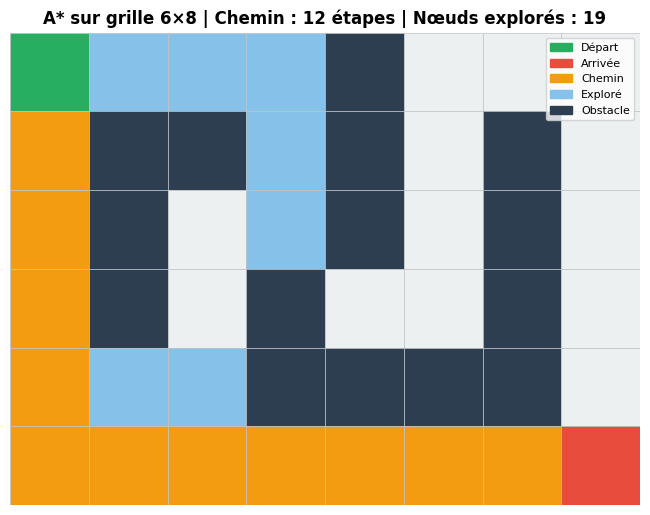

In [20]:
# --- Exercice 4 : Pathfinding sur grille avec A* ---

class GridProblem(Problem):
    """Problème de pathfinding sur une grille 2D avec obstacles.

    La grille est une liste de listes d'entiers :
      0 = cellule libre
      1 = obstacle (mur)
    L'état est un tuple (row, col).
    Les déplacements sont les 4 directions cardinales (haut, bas, gauche, droite).
    """

    DIRECTIONS = {
        'H': (-1,  0),   # Haut
        'B': ( 1,  0),   # Bas
        'G': ( 0, -1),   # Gauche
        'D': ( 0,  1),   # Droite
    }

    def __init__(self, grid, start, goal):
        super().__init__(start, goal)
        self.grid = grid
        self.rows = len(grid)
        self.cols = len(grid[0])

    def actions(self, state):
        """Retourne les directions valides depuis state (sans sortir ni toucher un mur)."""
        row, col = state
        valid = []
        for action, (dr, dc) in self.DIRECTIONS.items():
            nr, nc = row + dr, col + dc
            if 0 <= nr < self.rows and 0 <= nc < self.cols and self.grid[nr][nc] == 0:
                valid.append(action)
        return valid

    def result(self, state, action):
        """Retourne le nouvel état après déplacement."""
        row, col = state
        dr, dc = self.DIRECTIONS[action]
        return (row + dr, col + dc)


def manhattan_distance_grid(state, goal):
    """Distance Manhattan pour la grille."""
    return abs(state[0] - goal[0]) + abs(state[1] - goal[1])


def visualize_grid_search(grid, result, start, goal):
    """Visualise la grille avec le chemin et les nœuds explorés."""
    rows, cols = len(grid), len(grid[0])
    explored_set = set(result.explored_order)
    path_set = set(result.path)

    fig, ax = plt.subplots(figsize=(cols * 0.7 + 1, rows * 0.7 + 1))

    for r in range(rows):
        for c in range(cols):
            if grid[r][c] == 1:
                color = '#2C3E50'   # mur : gris foncé
            elif (r, c) == start:
                color = '#27AE60'   # départ : vert
            elif (r, c) == goal:
                color = '#E74C3C'   # arrivée : rouge
            elif (r, c) in path_set:
                color = '#F39C12'   # chemin : orange
            elif (r, c) in explored_set:
                color = '#85C1E9'   # exploré : bleu clair
            else:
                color = '#ECF0F1'   # libre : blanc cassé

            rect = plt.Rectangle((c, rows - 1 - r), 1, 1,
                                  facecolor=color, edgecolor='#BDC3C7', linewidth=0.5)
            ax.add_patch(rect)

    # Légende
    legend_items = [
        mpatches.Patch(color='#27AE60', label='Départ'),
        mpatches.Patch(color='#E74C3C', label='Arrivée'),
        mpatches.Patch(color='#F39C12', label='Chemin'),
        mpatches.Patch(color='#85C1E9', label='Exploré'),
        mpatches.Patch(color='#2C3E50', label='Obstacle'),
    ]
    ax.legend(handles=legend_items, loc='upper right', fontsize=8)

    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(
        f"A* sur grille {rows}×{cols} | "
        f"Chemin : {len(result.path)-1} étapes | "
        f"Nœuds explorés : {result.nodes_expanded}",
        fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


# --- Grille de test ---
grid = [
    [0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 0, 1, 0],
    [0, 0, 0, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
]

start = (0, 0)
goal  = (5, 7)

grid_problem = GridProblem(grid, start, goal)
h_grid = lambda s: manhattan_distance_grid(s, goal)

# Résoudre avec A*
result_grid = a_star_search(grid_problem, h_grid)

print(f"Problème de pathfinding sur une grille {len(grid)}×{len(grid[0])}")
print(f"Départ : {start}, Arrivée : {goal}")
print(f"Solution trouvée : {result_grid.found}")
if result_grid.found:
    print(f"Longueur du chemin : {len(result_grid.path) - 1} étapes")
    print(f"Nœuds explorés    : {result_grid.nodes_expanded}")
    print(f"Chemin : {result_grid.path}")

visualize_grid_search(grid, result_grid, start, goal)


### Exercice 5 : Pathfinding sur grille ponderee (couts de terrain)

L'exemple Ex4 utilise une grille binaire (libre / obstacle) ou chaque deplacement coute 1. En pratique, les cartes ont des **terrains varies** : route rapide, herbe, boue, eau... chacun avec un cout different. A* reste optimal a condition d'utiliser une heuristique admissible **adaptee au cout minimum de terrain**.

**Votre mission** : adapter A* pour une grille ou chaque cellule a un cout de traversee different.

1. Creez une classe `WeightedGridProblem` qui herite de `GridProblem` et overrider `step_cost(state, action, next_state)` pour retourner le **cout de la cellule d'arrivee** (lu dans la grille de couts). La grille passee au constructeur utilise la convention : $0 = \text{obstacle intraversable}$, $k \ge 1 = \text{cout de traversee}$ (**convention inverse a Ex4**, qui utilisait $0 = \text{libre}$, $1 = \text{mur}$).

2. Implementez une heuristique `weighted_manhattan(state, goal, min_cost)` :

   $$ h(n) = \text{Manhattan}(n, \text{goal}) \times c_{\min} $$

   ou $c_{\min}$ est le cout minimum non-nul present dans la grille. **Justifiez** pourquoi cette heuristique est admissible.

3. Testez votre implementation sur la grille de cout ci-dessous (terrain mixte : herbe = 2, boue = 3, eau profonde = 5) ou $c_{\min} = 2$. Comparez avec A* qui utilise la **Manhattan pure** (sans ponderation). Les deux algorithmes trouvent le meme cout optimal, mais la version ponderee explore **strictement moins de noeuds** car son heuristique est plus informative.

4. Interpretez : pourquoi l'heuristique ponderee guide-t-elle mieux A* ? Que se passe-t-il si on multiplie par un facteur $c > c_{\min}$ (non admissible) ?

**Lien avec la theorie de la dominance** (section 6) : $h_w = c_{\min} \cdot h_{\text{Manhattan}}$ domine $h_{\text{Manhattan}}$ tant que $c_{\min} \ge 1$. Domination stricte quand $c_{\min} > 1$.


In [21]:
# --- Exercice 5 : Pathfinding sur grille ponderee ---

# TODO: Implementer la classe WeightedGridProblem (sous-classe de GridProblem)
# class WeightedGridProblem(GridProblem):
#     """Grille ponderee : chaque cellule a un cout de traversee (entier >= 1).
#     Convention inverse de GridProblem : 0 = obstacle, k >= 1 = cout.
#     """
#
#     def actions(self, state):
#         # Meme logique que GridProblem, mais obstacle == cout 0
#         row, col = state
#         valid = []
#         for action, (dr, dc) in self.DIRECTIONS.items():
#             nr, nc = row + dr, col + dc
#             if 0 <= nr < self.rows and 0 <= nc < self.cols and self.grid[nr][nc] > 0:
#                 valid.append(action)
#         return valid
#
#     def step_cost(self, state, action, next_state):
#         # TODO: cout = valeur de la cellule d'arrivee dans la grille
#         raise NotImplementedError


# TODO: Implementer l'heuristique ponderee
# def weighted_manhattan(state, goal, min_cost):
#     """Manhattan * min_cost : borne inferieure sur le cout restant.
#     Admissible si min_cost <= cout reel de chaque cellule.
#     """
#     # TODO: calculer Manhattan et multiplier par min_cost
#     raise NotImplementedError


# Grille ponderee de test : herbe=2, boue=3, eau profonde=5, obstacle=0
# Tous les terrains traversables ont un cout >= 2, donc min_cost = 2.
# L'heuristique ponderee (manhattan * 2) est strictement plus informative
# que la manhattan brute (manhattan * 1), tout en restant admissible.
weighted_grid = [
    [2, 2, 2, 2, 2, 2, 2, 2],
    [2, 3, 3, 3, 0, 2, 2, 2],
    [2, 3, 5, 5, 0, 2, 0, 2],
    [2, 3, 5, 5, 0, 2, 0, 2],
    [2, 3, 3, 3, 2, 2, 0, 2],
    [2, 2, 2, 2, 2, 2, 2, 2],
]
start_w = (0, 0)
goal_w = (5, 7)

# TODO: Lancer A* avec l'heuristique ponderee et comparer avec Manhattan pure
#
# min_cost = min(v for row in weighted_grid for v in row if v > 0)  # = 2 ici
# problem_w = WeightedGridProblem(weighted_grid, start_w, goal_w)
#
# # A* avec heuristique ponderee (manhattan * min_cost)
# h_weighted = lambda s: weighted_manhattan(s, goal_w, min_cost)
# result_w = a_star_search(problem_w, h_weighted)
#
# # A* avec Manhattan pure (admissible mais moins informative)
# h_plain = lambda s: manhattan_distance_grid(s, goal_w)
# result_plain = a_star_search(problem_w, h_plain)
#
# print(f"Heuristique ponderee (x{min_cost}) : {result_w.nodes_expanded} noeuds, cout = {result_w.cost:.1f}")
# print(f"Heuristique Manhattan brute  : {result_plain.nodes_expanded} noeuds, cout = {result_plain.cost:.1f}")
# assert abs(result_w.cost - result_plain.cost) < 1e-6, "Les deux heuristiques doivent trouver le meme cout optimal"

# TODO: Interpreter : quelle heuristique explore moins de noeuds ? Pourquoi ?
# Redigez votre analyse dans une cellule markdown ci-dessous.

print("Exercice 5 : implementez les TODO ci-dessus.")


Exercice 5 : implementez les TODO ci-dessus.


## 10. Conclusion

### Concepts clés

| Concept | Définition |
|---------|------------|
| **Heuristique $h(n)$** | Estimation du coût restant de $n$ au but |
| **Admissible** | $h(n) \leq h^*(n)$ (ne surestime jamais) |
| **Consistante** | $h(n) \leq c(n, n') + h(n')$ (monotone) |
| **Dominance** | $h_1 \geq h_2$ : $h_1$ est plus informée |
| **f(n) = g(n) + h(n)** | Fonction d'évaluation de A* |

### Algorithmes

| Algorithme | Critère | Optimal | Mémoire |
|------------|----------|---------|----------|
| Greedy | Minimiser $h(n)$ | Non | $O(b^m)$ |
| A* | Minimiser $g(n) + h(n)$ | Oui (si $h$ admissible) | $O(b^d)$ |
| IDA* | DFS itéré par $f(n)$ | Oui | $O(bd)$ |

### Ce qu'il faut retenir

1. **L'heuristique est la clé** : une bonne heuristique peut réduire l'explosion combinatoire de plusieurs ordres de grandeur
2. **A* est l'algo de référence** : optimal avec heuristique admissible, utilisable dans la plupart des cas
3. **Greedy pour la vitesse** : quand une solution « assez bonne » suffit
4. **IDA* pour la mémoire** : même optimalité que A*, avec une consommation linéaire
5. **La dominance** : une heuristique plus informée (dominante) explore toujours moins de nœuds

### Pour aller plus loin

- **Notebook suivant** : [Search-4-LocalSearch](Search-4-LocalSearch.ipynb) — Hill Climbing, Simulated Annealing, Tabu Search
- **Applications** : Voir [Sudoku-7-Norvig](../../Sudoku/Sudoku-7-Norvig.ipynb) pour l'application de la propagation de contraintes (inspirée de la recherche informée)
- **Référence** : Russell & Norvig, *Artificial Intelligence: A Modern Approach*, Chapitre 3.5 — Heuristic Functions

---

**Navigation** : [<< Recherche non informée](Search-2-Uninformed.ipynb) | [Index](../README.md) | [Recherche locale >>](Search-4-LocalSearch.ipynb)


## Conclusion et perspectives

Ce notebook a présenté les algorithmes de recherche informée, qui utilisent des connaissances spécifiques du problème (heuristiques) pour guider l'exploration. L'efficacité de ces algorithmes dépend crucialement de la qualité de l'heuristique.

**Prochain notebook** : [Search-4-LocalSearch](Search-4-LocalSearch.ipynb) — Découvrez les algorithmes de recherche locale (Hill Climbing, Simulated Annealing, Tabu Search) qui explorent l'espace de recherche de manière différente, sans maintenir de frontière explicite.
